# 1. Importación de las librerías necesarias

In [ ]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


In [ ]:
plt.style.use('ggplot')
sns.set(style="whitegrid")

# 2. Carga y visualización de los datos

In [ ]:
df = pd.read_csv("/content/dataframe.csv")


In [ ]:
columnas_cuantitativas = [
    'Elevation', 'Aspect', 'Slope',
    'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways',
    'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
    'Horizontal_Distance_To_Fire_Points'
]

columnas_wilderness = [f'Wilderness_Area_{i}' for i in range(1, 5)]

columnas_soil = [f'Soil_Type_{i}' for i in range(1, 41)]

columna_target = ['Cover_Type']

todas_columnas = columnas_cuantitativas + columnas_wilderness + columnas_soil + columna_target

df.columns = todas_columnas

In [ ]:
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area_1,Wilderness_Area_2,Wilderness_Area_3,Wilderness_Area_4,Soil_Type_1,Soil_Type_2,Soil_Type_3,Soil_Type_4,Soil_Type_5,Soil_Type_6,Soil_Type_7,Soil_Type_8,Soil_Type_9,Soil_Type_10,Soil_Type_11,Soil_Type_12,Soil_Type_13,Soil_Type_14,Soil_Type_15,Soil_Type_16,Soil_Type_17,Soil_Type_18,Soil_Type_19,Soil_Type_20,Soil_Type_21,Soil_Type_22,Soil_Type_23,Soil_Type_24,Soil_Type_25,Soil_Type_26,Soil_Type_27,Soil_Type_28,Soil_Type_29,Soil_Type_30,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Soil_Type_40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,5


In [ ]:
import pandas as pd

# Mostrar todas las columnas
pd.set_option('display.max_columns', None)

# Ahora puedes usar .head() y ver todas las columnas
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area_1,Wilderness_Area_2,Wilderness_Area_3,Wilderness_Area_4,Soil_Type_1,Soil_Type_2,Soil_Type_3,Soil_Type_4,Soil_Type_5,Soil_Type_6,Soil_Type_7,Soil_Type_8,Soil_Type_9,Soil_Type_10,Soil_Type_11,Soil_Type_12,Soil_Type_13,Soil_Type_14,Soil_Type_15,Soil_Type_16,Soil_Type_17,Soil_Type_18,Soil_Type_19,Soil_Type_20,Soil_Type_21,Soil_Type_22,Soil_Type_23,Soil_Type_24,Soil_Type_25,Soil_Type_26,Soil_Type_27,Soil_Type_28,Soil_Type_29,Soil_Type_30,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Soil_Type_40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,5


# 3. Eliminación de los duplicados

In [ ]:
df.duplicated().sum()


np.int64(0)

# 4. Análisis general de las variables

In [ ]:
# 1. Información general del dataset
print("Dimensiones del dataset:", df.shape)
print("\nInformación del dataset:")
df.info()

print("\nEstadísticas descriptivas:")
display(df.describe())

Dimensiones del dataset: (581012, 55)

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area_1                   581012 non-null 

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area_1,Wilderness_Area_2,Wilderness_Area_3,Wilderness_Area_4,Soil_Type_1,Soil_Type_2,Soil_Type_3,Soil_Type_4,Soil_Type_5,Soil_Type_6,Soil_Type_7,Soil_Type_8,Soil_Type_9,Soil_Type_10,Soil_Type_11,Soil_Type_12,Soil_Type_13,Soil_Type_14,Soil_Type_15,Soil_Type_16,Soil_Type_17,Soil_Type_18,Soil_Type_19,Soil_Type_20,Soil_Type_21,Soil_Type_22,Soil_Type_23,Soil_Type_24,Soil_Type_25,Soil_Type_26,Soil_Type_27,Soil_Type_28,Soil_Type_29,Soil_Type_30,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Soil_Type_40,Cover_Type
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,155.656807,14.103704,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226,0.448865,0.051434,0.436074,0.063627,0.005217,0.012952,0.008301,0.021335,0.002749,0.011316,0.000181,0.000308,0.001974,0.056168,0.021359,0.051584,0.030001,0.001031,0.000005,0.004897,0.005890,0.003268,0.006921,0.015936,0.001442,0.057439,0.099399,0.036622,0.000816,0.004456,0.001869,0.001628,0.198356,0.051927,0.044175,0.090392,0.077716,0.002773,0.003255,0.000205,0.000513,0.026803,0.023762,0.015060,2.051471
std,279.984734,111.913721,7.488242,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210,0.497379,0.220882,0.495897,0.244087,0.072039,0.113066,0.090731,0.144499,0.052356,0.105775,0.013442,0.017550,0.044387,0.230245,0.144579,0.221186,0.170590,0.032092,0.002272,0.069804,0.076518,0.057077,0.082902,0.125228,0.037950,0.232681,0.299197,0.187833,0.028551,0.066605,0.043193,0.040318,0.398762,0.221879,0.205483,0.286743,0.267725,0.052584,0.056957,0.014310,0.022641,0.161508,0.152307,0.121791,1.396504
min,1859.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000

| Variable                                   | Tipo       | Descripción                                                               |
| ------------------------------------------ | ---------- | ------------------------------------------------------------------------- |
| **Elevation**                              | Numérica   | Altitud en metros sobre el nivel del mar.                                 |
| **Aspect**                                 | Numérica   | Orientación del terreno en grados (0° = norte, 90° = este, etc.).         |
| **Slope**                                  | Numérica   | Pendiente del terreno en grados.                                          |
| **Horizontal\_Distance\_To\_Hydrology**    | Numérica   | Distancia horizontal al agua más cercana (río/lago), en metros.           |
| **Vertical\_Distance\_To\_Hydrology**      | Numérica   | Diferencia de elevación respecto al agua más cercana, en metros.          |
| **Horizontal\_Distance\_To\_Roadways**     | Numérica   | Distancia horizontal a la carretera más cercana, en metros.               |
| **Hillshade\_9am**                         | Numérica   | Índice de sombra a las 9 am (0 a 255).                                    |
| **Hillshade\_Noon**                        | Numérica   | Índice de sombra a las 12 pm (mediodía).                                  |
| **Hillshade\_3pm**                         | Numérica   | Índice de sombra a las 3 pm.                                              |
| **Horizontal\_Distance\_To\_Fire\_Points** | Numérica   | Distancia horizontal a un punto de control de incendios, en metros.       |
| **Wilderness\_Area\_1**                    | Binaria    | 1 si el área es Rawah Wilderness, 0 si no.                                |
| **Wilderness\_Area\_2**                    | Binaria    | 1 si el área es Neota Wilderness, 0 si no.                                |
| **Wilderness\_Area\_3**                    | Binaria    | 1 si el área es Comanche Peak Wilderness, 0 si no.                        |
| **Wilderness\_Area\_4**                    | Binaria    | 1 si el área es Cache la Poudre Wilderness, 0 si no.                      |
| **Soil\_Type\_1** – **Soil\_Type\_40**     | Binaria    | Codificación one-hot de 40 tipos de suelo. Solo uno es 1 por observación. |
| **Cover\_Type**                            | Categórica | Variable objetivo (1–7), indica el tipo de cobertura forestal.            |


| Valor | Tipo de cobertura forestal |
| ----- | -------------------------- |
| 1     | Spruce/Fir                 |
| 2     | Lodgepole Pine             |
| 3     | Ponderosa Pine             |
| 4     | Cottonwood/Willow          |
| 5     | Aspen                      |
| 6     | Douglas-fir                |
| 7     | Krummholz                  |


In [2]:
import requests
from bs4 import BeautifulSoup
import re

tipos_cobertura_alternativas = {
    "Spruce-fir forest": ["Spruce-fir forest", "Spruce fir", "Subalpine forest"],
    "Lodgepole pine": ["Lodgepole pine", "Pinus contorta"],
    "Ponderosa pine": ["Ponderosa pine", "Pinus ponderosa", "Ponderosa Pine tree"],
    "Cottonwood": ["Cottonwood", "Populus", "Cottonwood tree", "Populus deltoides"],
    "Aspen": ["Aspen", "Populus tremuloides"],
    "Douglas fir": ["Douglas fir", "Pseudotsuga menziesii"],
    "Krummholz": ["Krummholz"]
}

def limpiar_referencias(texto):
    # Quitar números entre corchetes, ej. [1], [2], etc.
    return re.sub(r'\[\d+\]', '', texto)

def obtener_descripcion_wikipedia(terminos):
    for termino in terminos:
        url = f"https://en.wikipedia.org/wiki/{termino.replace(' ', '_')}"
        try:
            r = requests.get(url, timeout=10)
            r.raise_for_status()
            soup = BeautifulSoup(r.text, 'html.parser')

            contenido = soup.find('div', {'class':'mw-parser-output'})
            if not contenido:
                continue

            parrafos = contenido.find_all('p')
            for p in parrafos:
                texto = p.get_text(strip=True)
                texto = limpiar_referencias(texto)
                if len(texto) > 100:
                    return texto[:3000] + "..."
        except requests.HTTPError:
            continue
        except Exception:
            continue
    return "Descripción no encontrada."

with open("tipos_cobertura_forestal_limpio_3000.txt", "w", encoding="utf-8") as f:
    for tipo, alternativas in tipos_cobertura_alternativas.items():
        descripcion = obtener_descripcion_wikipedia(alternativas)
        f.write(f"Tipo de Cobertura Forestal: {tipo}\n")
        f.write(f"Descripción: {descripcion}\n")
        f.write("\n" + "-"*80 + "\n\n")

print("✅ Archivo 'tipos_cobertura_forestal_limpio_3000.txt' creado correctamente.")


✅ Archivo 'tipos_cobertura_forestal_limpio_3000.txt' creado correctamente.


In [ ]:
# 2. Verificamos valores nulos
print("\nValores nulos por columna:")
display(df.isnull().sum())


Valores nulos por columna:


,0
Elevation,0
Aspect,0
Slope,0
Horizontal_Distance_To_Hydrology,0
Vertical_Distance_To_Hydrology,0
Horizontal_Distance_To_Roadways,0
Hillshade_9am,0
Hillshade_Noon,0
Hillshade_3pm,0
Horizontal_Distance_To_Fire_Points,0


A través de un primer vistazo podemos observar la presencia de 55 variables. Esto puede parecer una gran cantidad, sin embargo si prestamos atención vemos que la mayoría no dejan de ser columnas referentes a Soil_type, lo que nos hace pensar que se debe a que en un primer momento esta era una variable categórica que más tarde ha sido codificada mediante one-hot encoding, ahorrandonos por tanto este paso en la fase de modelado. Sucede lo mismo con las distintas variables refentes a Wilderness_Area. Sumado esto a que todas las variables son númericas, en el proceso de modelado por tanto no aumentaremos de variables. Continuando con este primer análsis observamos que no hay valores nulos en ninguna de las variables y que tampoco se han encontrado filas duplicadas.

# 5. Análsis de la variable objetivo

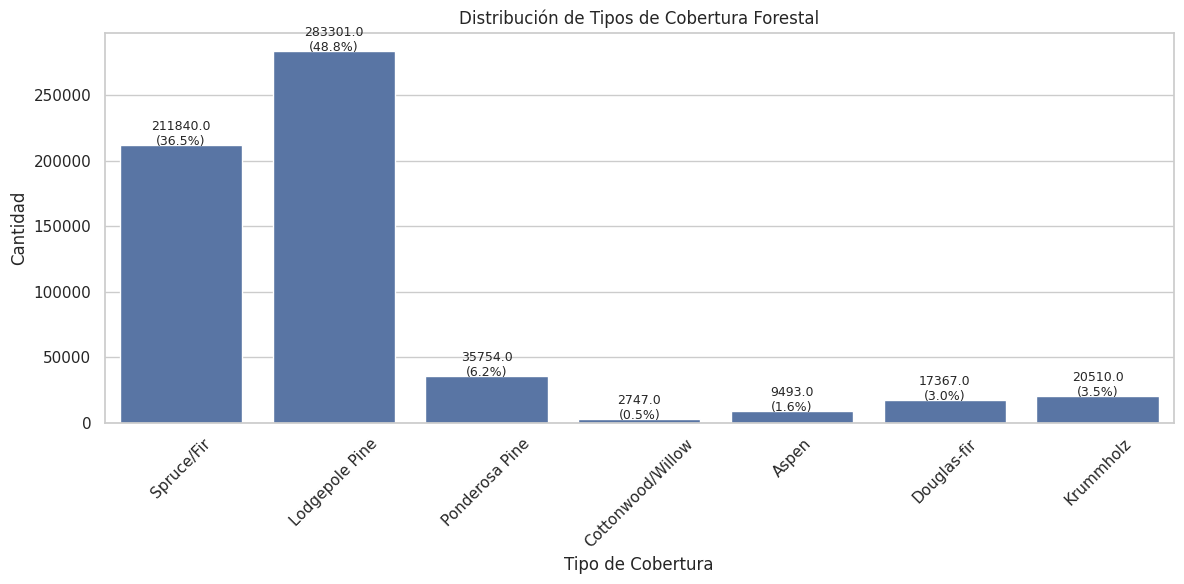

In [ ]:
# 3. Distribución de la variable objetivo
plt.figure(figsize=(12, 6))
ax = sns.countplot(x='Cover_Type', data=df)
plt.title('Distribución de Tipos de Cobertura Forestal')
plt.xlabel('Tipo de Cobertura')
plt.ylabel('Cantidad')


# Añadimos etiquetas con los nombres reales de las clases
etiquetas_clases = {
    1: 'Spruce/Fir',
    2: 'Lodgepole Pine',
    3: 'Ponderosa Pine',
    4: 'Cottonwood/Willow',
    5: 'Aspen',
    6: 'Douglas-fir',
    7: 'Krummholz'
}

# Añadimos el conteo y porcentaje en cada barra
total = len(df)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2.,
            height + 3,
            f'{height}\n({height/total:.1%})',
            ha="center", fontsize=9)

plt.xticks(range(7), [etiquetas_clases[i+1] for i in range(7)], rotation=45)
plt.tight_layout()
plt.show()

Se observa un desbalanceo importante entre las clases Spruce/Fir y Lodgepole Pine respecto a los demás sumando estas dos categorías mas del 80% de los datos. Hablaremos de como tratar este desbalanceo más adelante.

# 6. Análisis de las variables cuantitativas

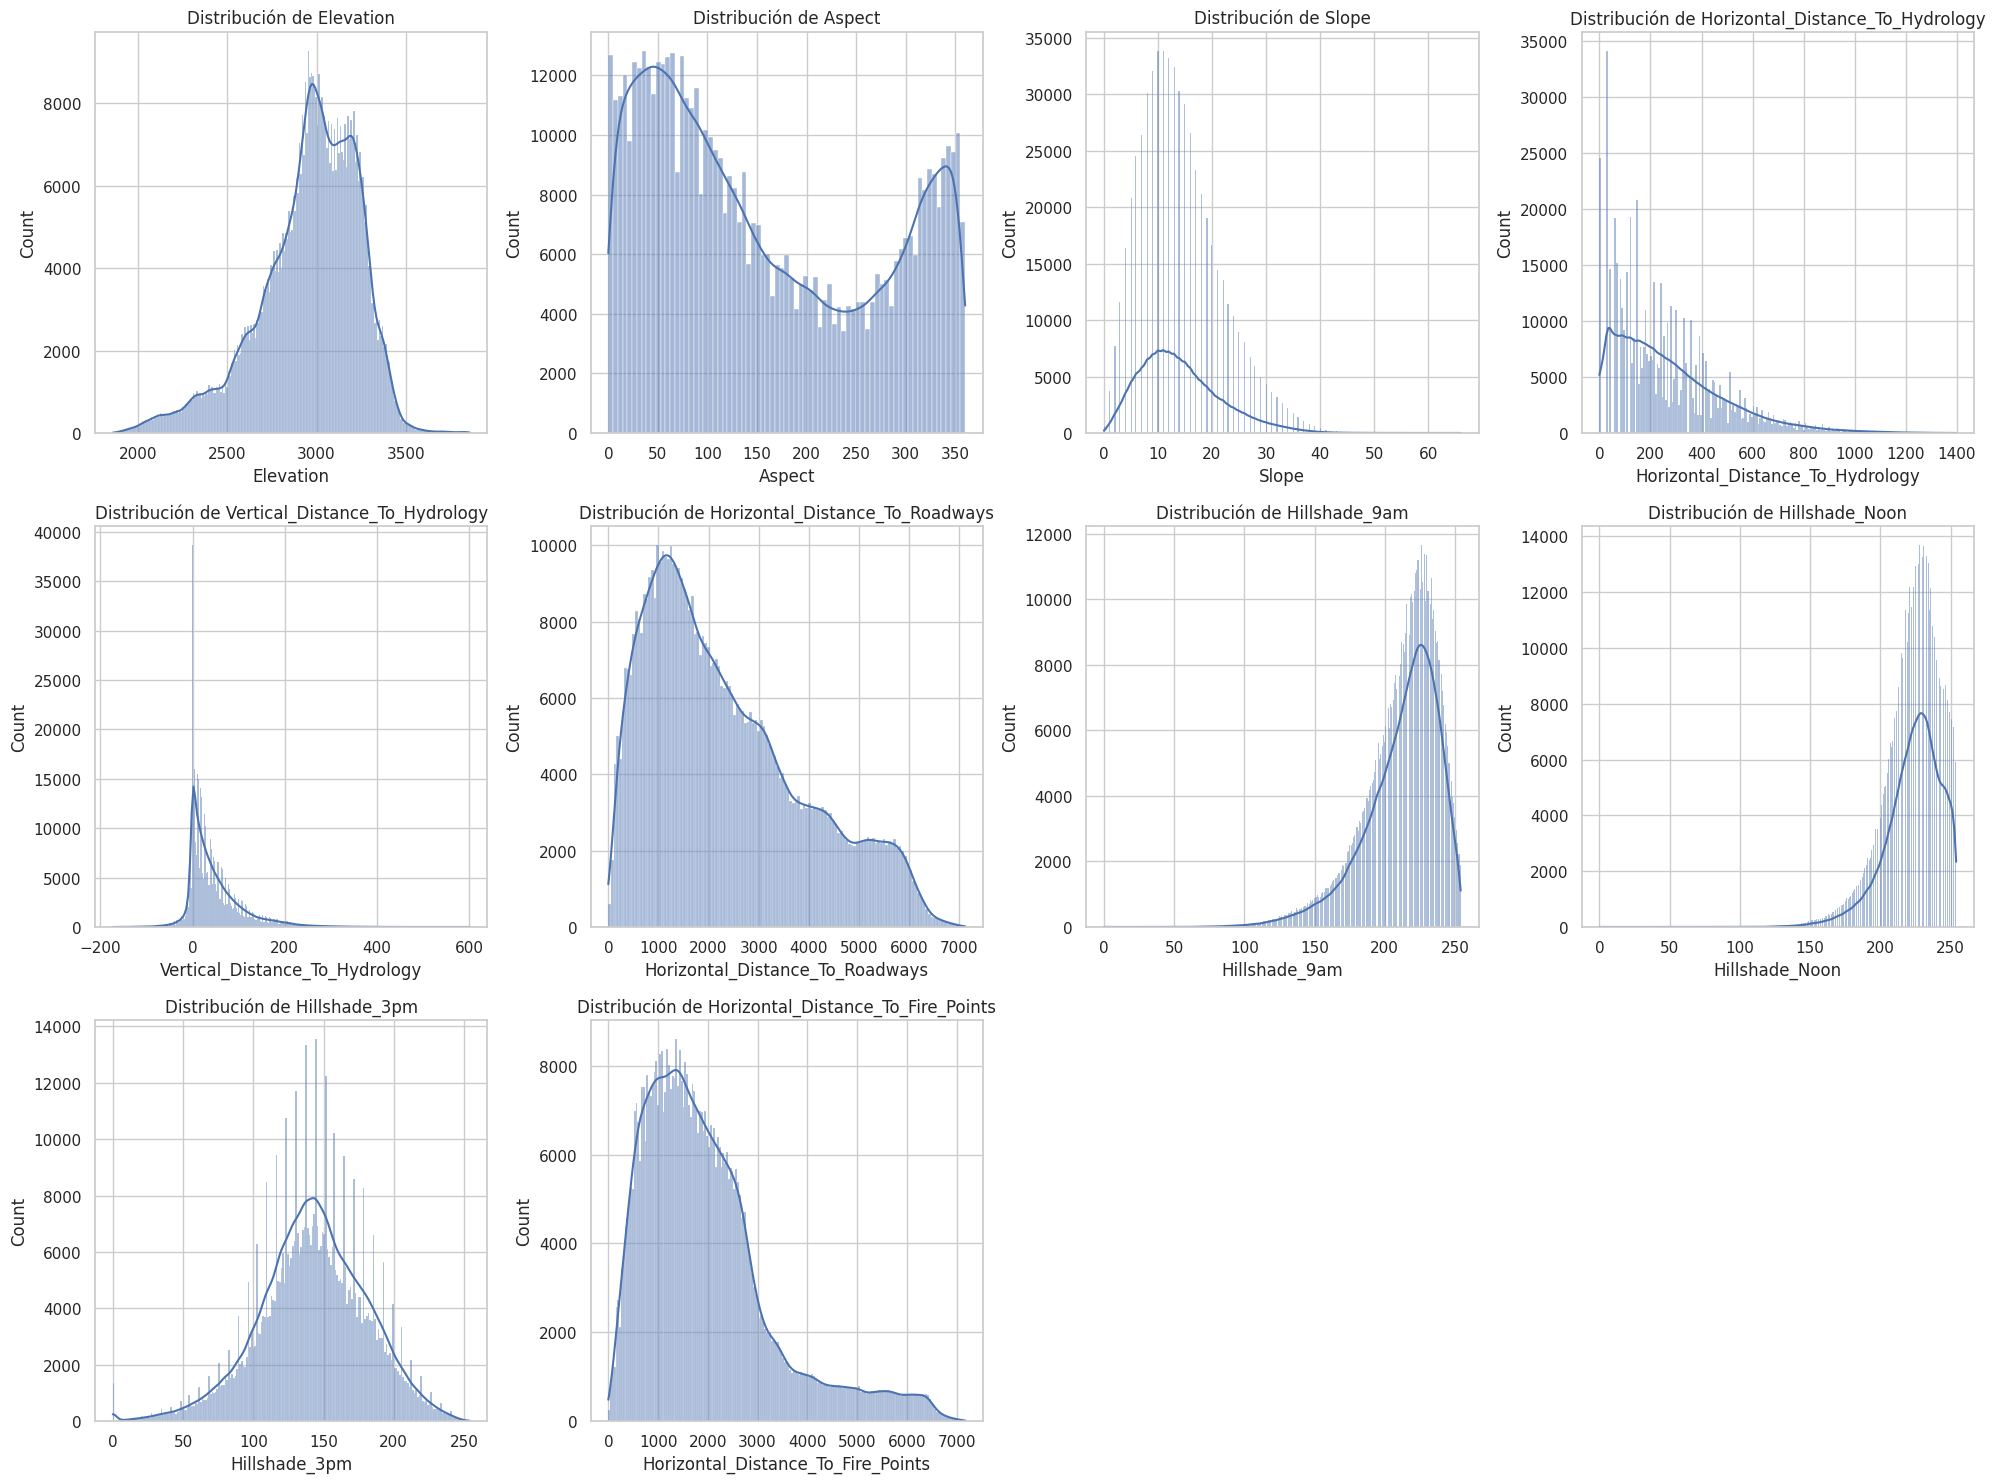

In [ ]:
# 4. Análisis de variables cuantitativas
# Histogramas para variables numéricas
plt.figure(figsize=(20, 15))
for i, col in enumerate(columnas_cuantitativas):
    plt.subplot(3, 4, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribución de {col}')
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import kurtosis
import pandas as pd

# Supongamos que tienes tu DataFrame
columnas_cuantitativas = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
                          'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
                          'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
                          'Horizontal_Distance_To_Fire_Points']

# Curtosis ajustada (por defecto fisher=True, lo que resta 3 → curtosis normal = 0)
curtosis_df = df[columnas_cuantitativas].apply(lambda x: kurtosis(x, fisher=True))

# Si prefieres la curtosis "clásica", pon fisher=False
# curtosis_df = df[columnas_cuantitativas].apply(lambda x: kurtosis(x, fisher=False))

curtosis_df


,0
Elevation,0.749234
Aspect,-1.220239
Slope,0.581184
Horizontal_Distance_To_Hydrology,1.366158
Vertical_Distance_To_Hydrology,5.250240
Horizontal_Distance_To_Roadways,-0.383718
Hillshade_9am,1.875491
Hillshade_Noon,2.066183
Hillshade_3pm,0.398426
Horizontal_Distance_To_Fire_Points,1.645782


Mediante los histogramas y la tabla de curtosis podemos sacar una serie de conclusiones, sin embargo, antes explicaremos o recordaremos levemente el concepto de curtosis.

La curtosis es una medida estadística que describe la forma de la distribución de una variable, particularmente en lo que respecta a la "altura" y "cola" de la distribución en comparación con una distribución normal.

📌 Tipos de curtosis

Curtosis baja (platocúrtica): Distribución con colas más delgadas y una forma más aplanada que la normal.

Curtosis normal (mesocúrtica): Distribución con curtosis alrededor de 0 (si se usa la curtosis ajustada), lo que indica forma similar a la normal.

Curtosis alta (leptocúrtica): Distribución con colas más pesadas y un pico más alto que la normal.

Una curtosis elevada puede indicar presencia de valores extremos o outliers.

📊 ¿Cómo interpretarla?

| Valor de curtosis (ajustada) | Interpretación                       |
| ---------------------------- | ------------------------------------ |
| ≈ 0                          | Distribución normal (mesocúrtica)    |
| < 0                          | Más plana, colas delgadas            |
| > 0                          | Más picuda, colas pesadas (outliers) |


<br>


| Variable                                   | Curtosis | Interpretación                                                     |
| ------------------------------------------ | -------- | ------------------------------------------------------------------ |
| **Elevation**                              | 0.75     | Leptocúrtica moderada: colas algo pesadas, algo de outliers        |
| **Aspect**                                 | -1.22    | Platicúrtica: distribución más plana, colas delgadas               |
| **Slope**                                  | 0.58     | Leptocúrtica leve: colas algo pesadas                              |
| **Horizontal\_Distance\_To\_Hydrology**    | 1.37     | Leptocúrtica: colas pesadas, posible presencia de outliers         |
| **Vertical\_Distance\_To\_Hydrology**      | 5.25     | Muy leptocúrtica: colas muy pesadas, alta probabilidad de outliers |
| **Horizontal\_Distance\_To\_Roadways**     | -0.38    | Casi mesocúrtica: distribución relativamente normal                |
| **Hillshade\_9am**                         | 1.88     | Leptocúrtica: colas pesadas, posibles outliers                     |
| **Hillshade\_Noon**                        | 2.07     | Leptocúrtica: colas pesadas, posibles outliers                     |
| **Hillshade\_3pm**                         | 0.40     | Leptocúrtica leve: colas algo pesadas                              |
| **Horizontal\_Distance\_To\_Fire\_Points** | 1.65     | Leptocúrtica: colas pesadas, posibles outliers                     |

<br>

**Resumen rápido:**

La mayoría de las variables tienen curtosis positiva, lo que indica que sus distribuciones tienen colas más pesadas que una normal — típico cuando hay outliers.

La variable Vertical_Distance_To_Hydrology destaca por una curtosis muy alta (5.25), lo que sugiere una cantidad significativa de valores extremos.

Algunas variables, como Aspect y Horizontal_Distance_To_Roadways, presentan distribución más plana (curtosis negativa), menos propensas a outliers extremos

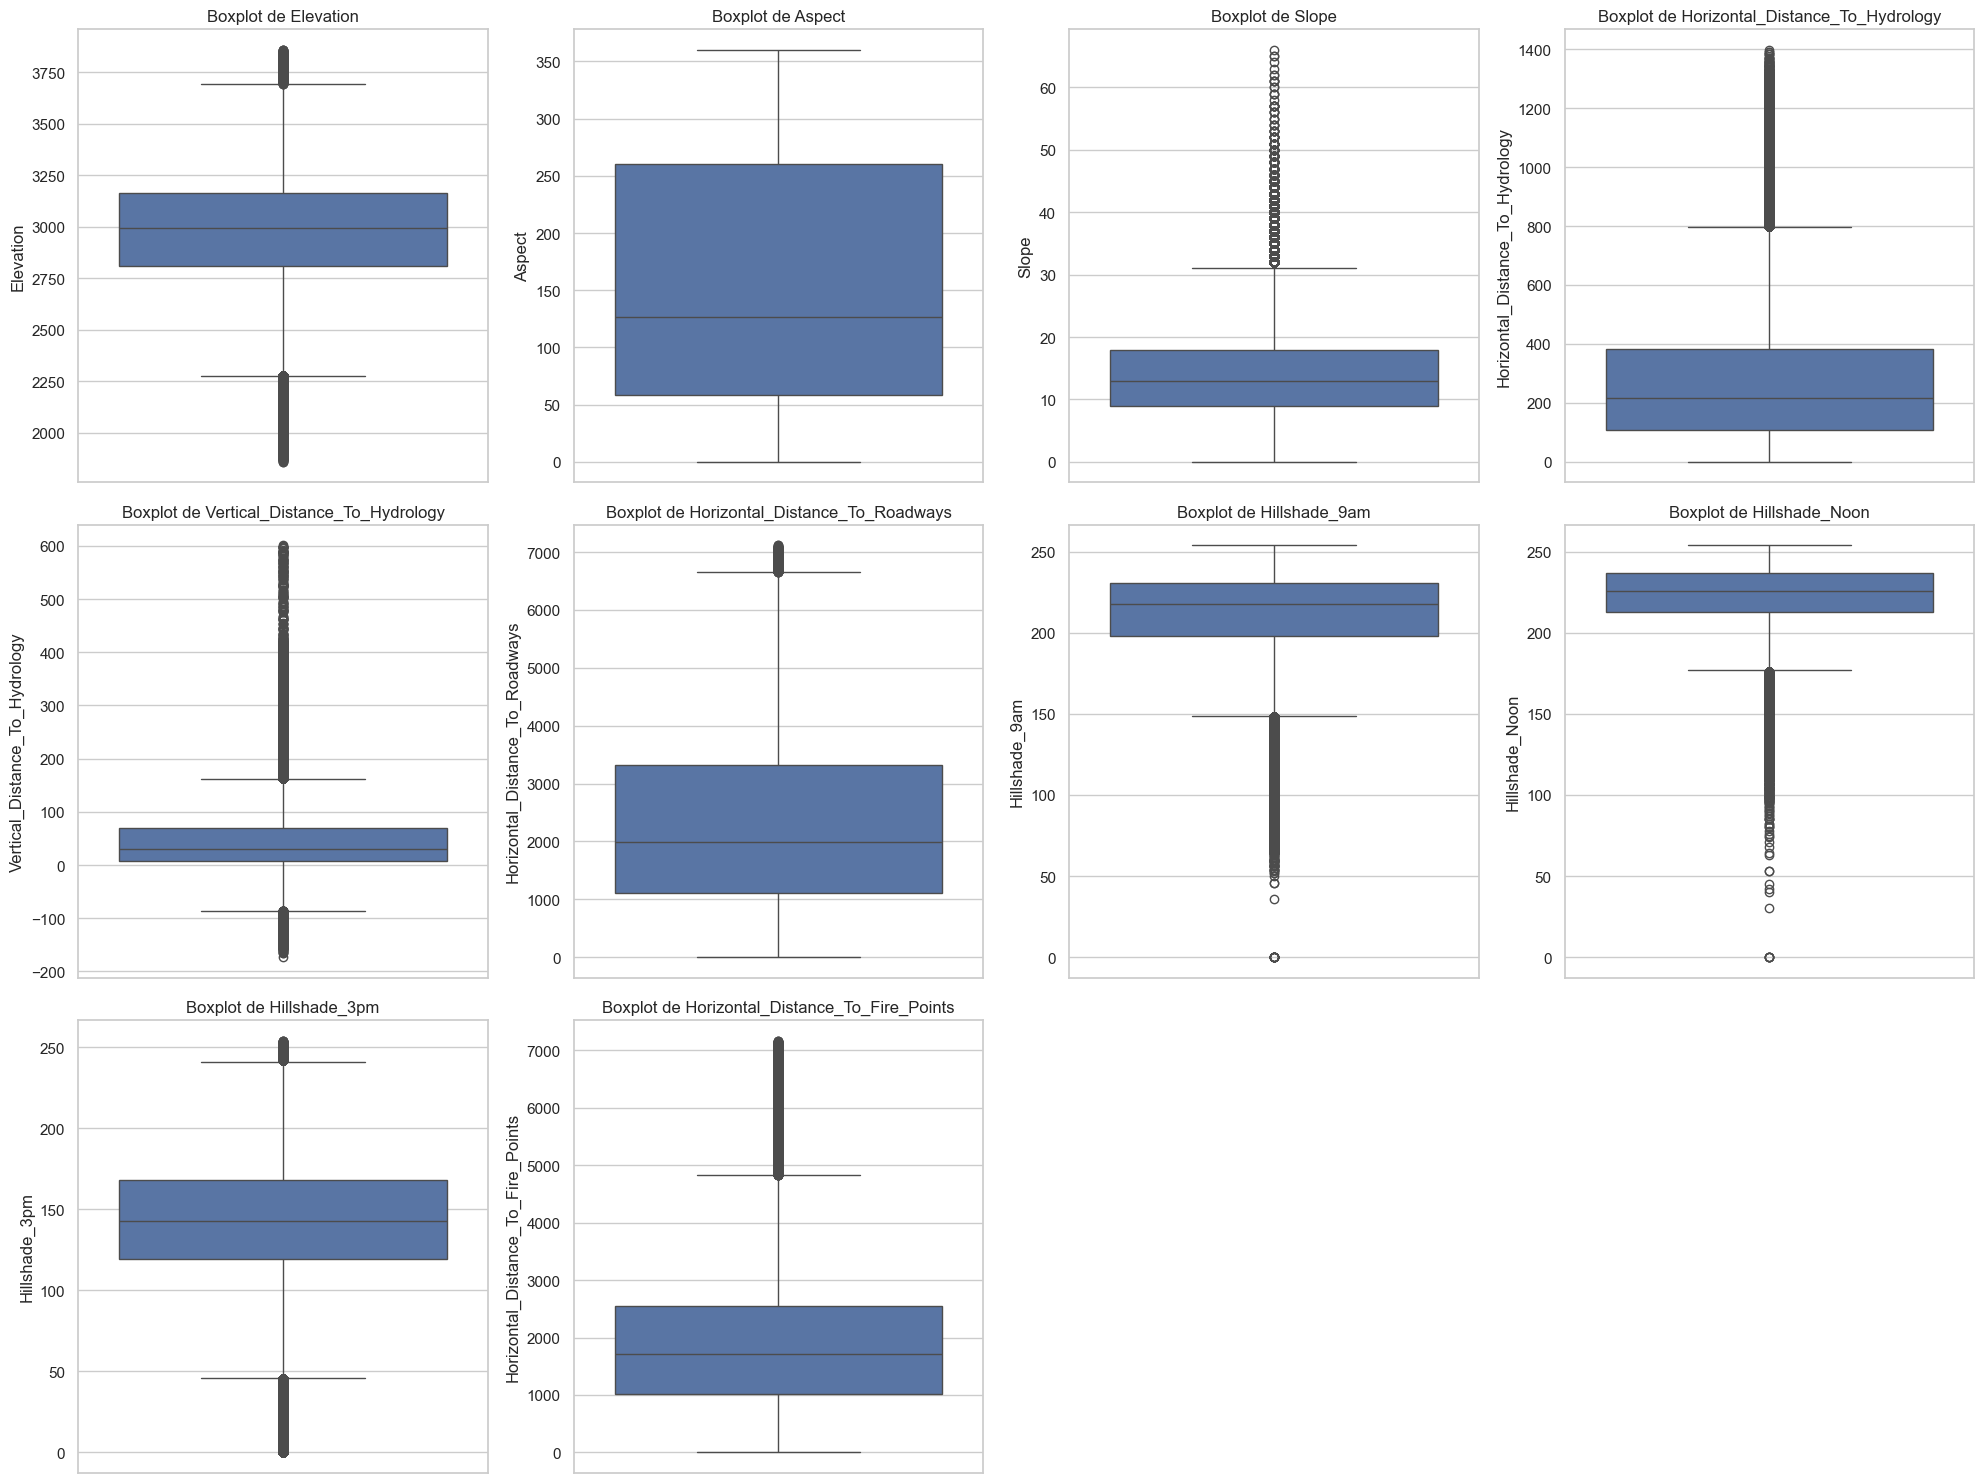

In [ ]:
# 5. Boxplots para detectar outliers en variables numéricas
plt.figure(figsize=(20, 15))
for i, col in enumerate(columnas_cuantitativas):
    plt.subplot(3, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

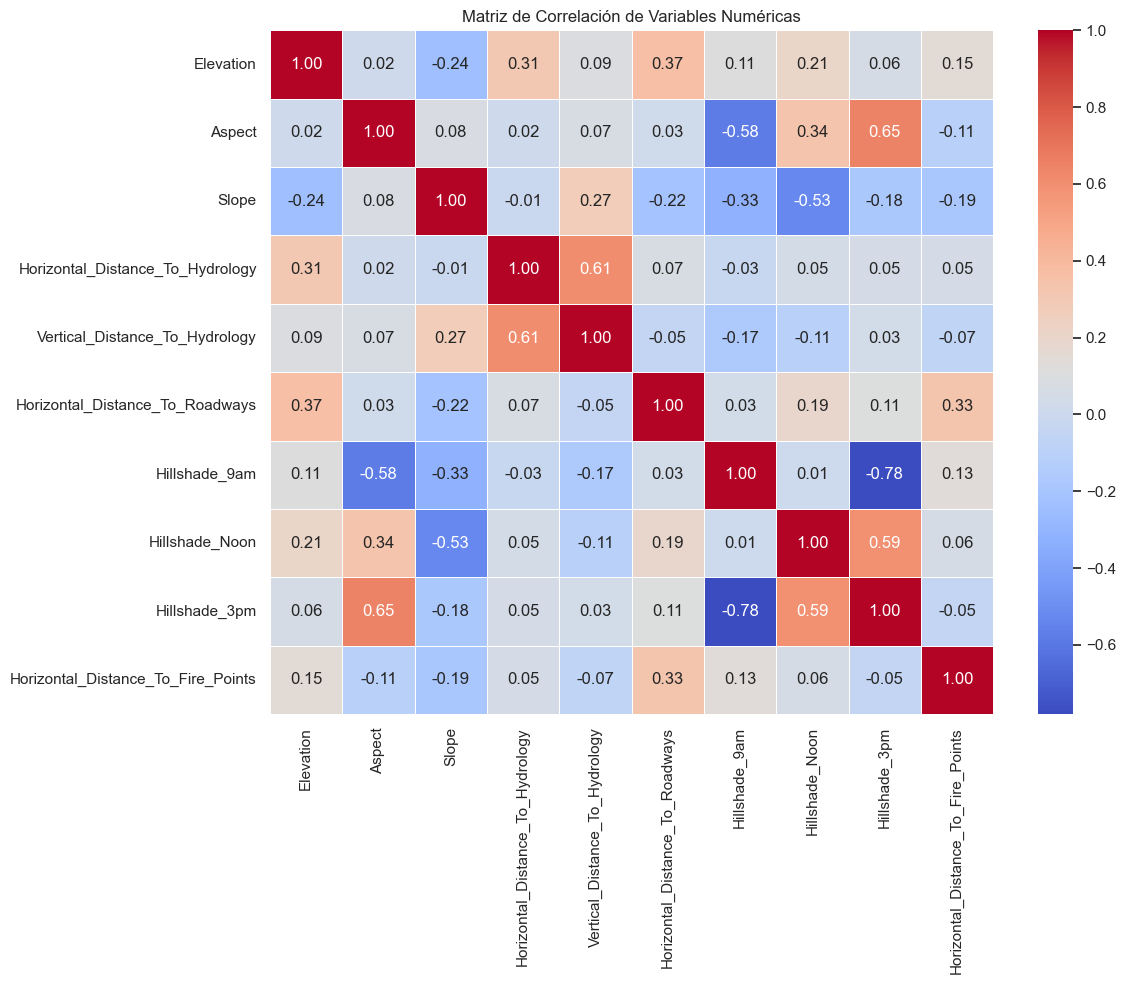

In [ ]:
# 6. Análisis de correlación entre variables numéricas
plt.figure(figsize=(12, 10))
correlation_matrix = df[columnas_cuantitativas].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.tight_layout()
plt.show()

# Comentario sobre la Matriz de Correlación


## Observaciones Generales:

1.  **Escala de Color:** Los colores cálidos (rojos) indican una correlación positiva (cuando una variable aumenta, la otra tiende a aumentar), mientras que los colores fríos (azules) indican una correlación negativa (cuando una variable aumenta, la otra tiende a disminuir). La intensidad del color refleja la fuerza de la correlación. Colores cercanos al blanco o muy pálidos indican una correlación débil o nula.
2.  **Diagonal Principal:** Todos los valores en la diagonal principal son **1.00** (rojo intenso), lo cual es esperado, ya que cada variable está perfectamente correlacionada consigo misma.

## Correlaciones Específicas Notables:

### Correlaciones Positivas Fuertes/Moderadas:
*   **`Aspect` y `Hillshade_3pm` (0.65):** Existe una correlación positiva moderada-fuerte. Esto sugiere que a medida que cambia la orientación de la ladera (`Aspect`), la cantidad de sombra a las 3 PM también cambia de forma predecible. Por ejemplo, laderas orientadas al oeste (mayor valor de `Aspect`, asumiendo 0=Norte) recibirán más sol por la tarde.
*   **`Horizontal_Distance_To_Hydrology` y `Vertical_Distance_To_Hydrology` (0.61):** Correlación positiva moderada-fuerte. Es lógico, ya que si un punto está horizontalmente lejos de una fuente de agua, es probable que también tenga una diferencia vertical significativa, especialmente en terrenos con pendiente.
*   **`Elevation` y `Horizontal_Distance_To_Roadways` (0.37):** Correlación positiva moderada. Podría indicar que las carreteras tienden a construirse a elevaciones más bajas, o que las áreas más elevadas están más alejadas de las carreteras.
*   **`Elevation` y `Horizontal_Distance_To_Hydrology` (0.31):** Similar a la anterior, las áreas más elevadas podrían estar más lejos de las fuentes de agua.

### Correlaciones Negativas Fuertes/Moderadas:
*   **`Hillshade_9am` y `Hillshade_3pm` (-0.78):** Correlación negativa muy fuerte. Esto es muy lógico: las laderas que reciben mucha luz solar por la mañana (alto `Hillshade_9am`) estarán en sombra por la tarde (bajo `Hillshade_3pm`), y viceversa. Son casi inversamente proporcionales.
*   **`Aspect` y `Hillshade_9am` (-0.58):** Correlación negativa moderada-fuerte. Indica que la orientación de la ladera influye en la sombra matutina. Por ejemplo, laderas orientadas al este (menor valor de `Aspect`) recibirán más sol por la mañana.
*   **`Slope` y `Hillshade_Noon` (-0.53):** Correlación negativa moderada. Laderas más empinadas (mayor `Slope`) tienden a tener menos iluminación directa al mediodía, posiblemente debido a que el sol cenital no incide tan perpendicularmente o se proyectan más sombras.

### Correlaciones Débiles:
*   Muchas variables muestran correlaciones muy débiles (valores cercanos a 0), por ejemplo, **`Elevation` y `Aspect` (0.02)**, **`Slope` y `Horizontal_Distance_To_Hydrology` (-0.01)**. Esto significa que hay poca o ninguna relación lineal directa entre ellas.



# 7. Relación entre variables numéricas y objetivo

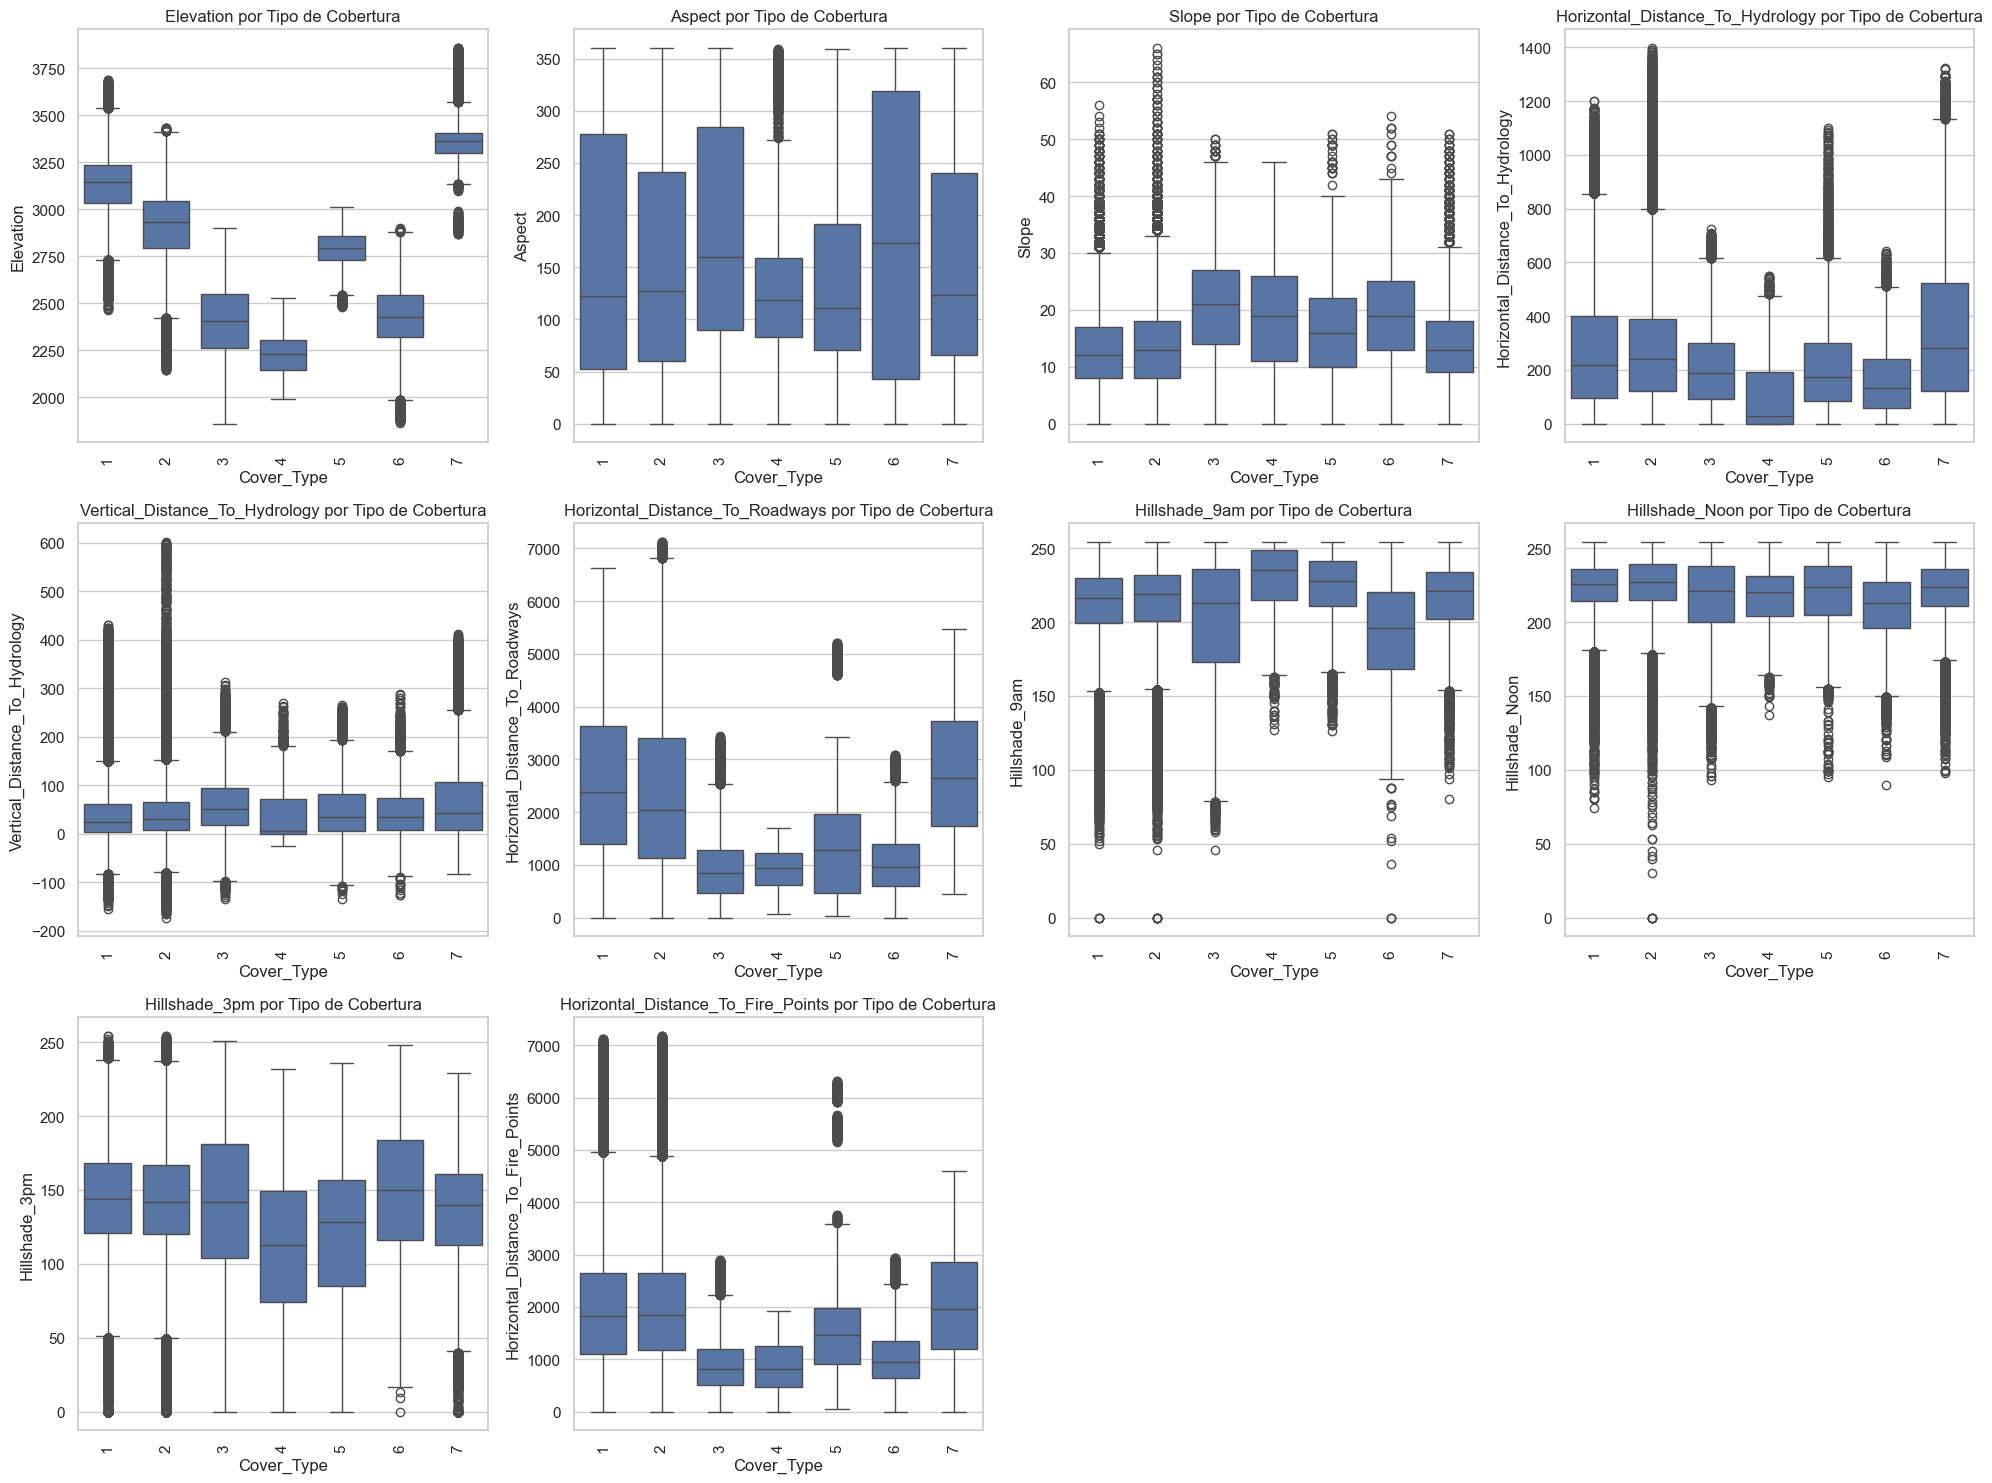

In [ ]:
# 7. Relación entre variables numéricas y la variable objetivo
plt.figure(figsize=(20, 15))
for i, col in enumerate(columnas_cuantitativas):
    plt.subplot(3, 4, i+1)
    sns.boxplot(x='Cover_Type', y=col, data=df)
    plt.title(f'{col} por Tipo de Cobertura')
    plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# 8. Otras distribuciones de las variables

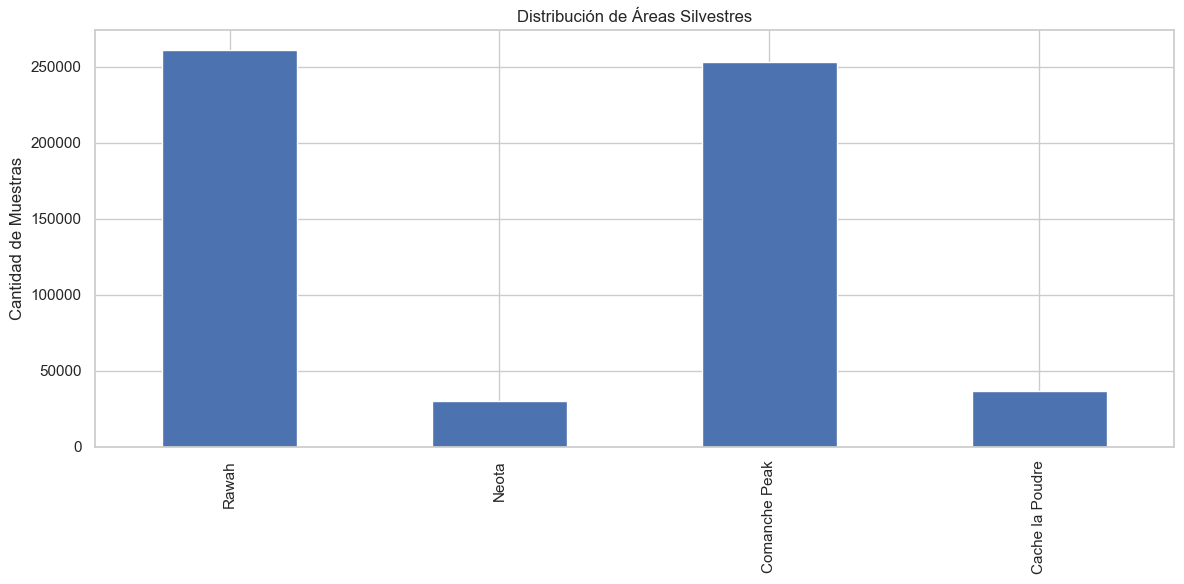

In [ ]:
# 8. Análisis de variables binarias (Wilderness Area)
plt.figure(figsize=(12, 6))
wilderness_counts = df[columnas_wilderness].sum()
wilderness_counts.index = ['Rawah', 'Neota', 'Comanche Peak', 'Cache la Poudre']
wilderness_counts.plot(kind='bar')
plt.title('Distribución de Áreas Silvestres')
plt.ylabel('Cantidad de Muestras')
plt.tight_layout()
plt.show()

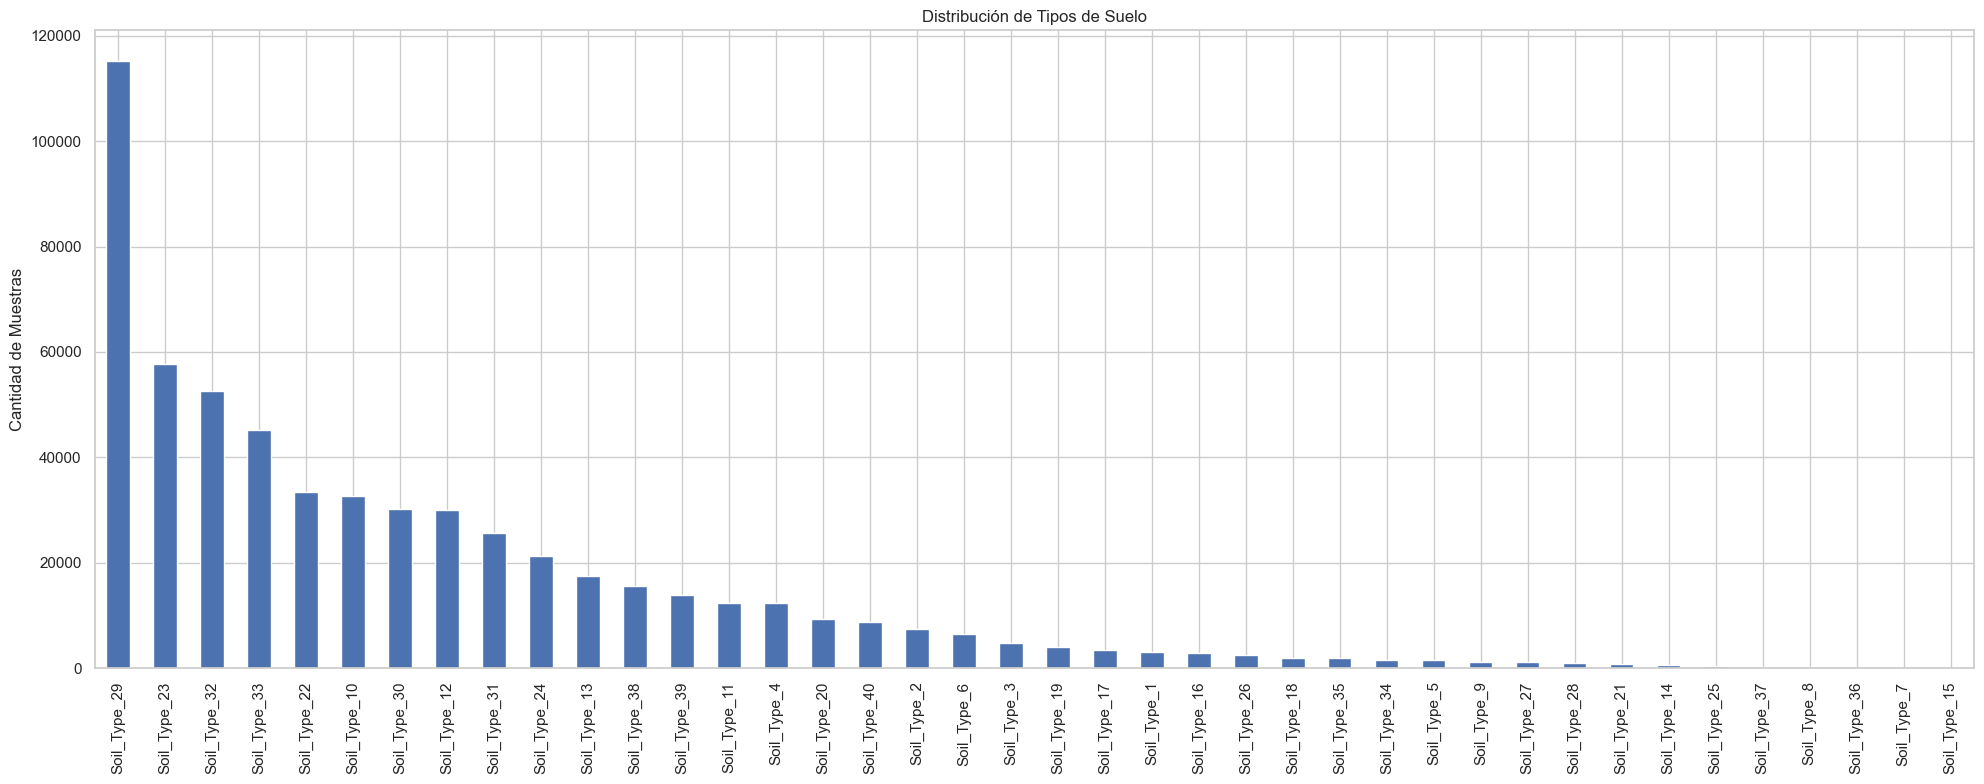

In [ ]:
# 9. Distribución de tipos de suelo
plt.figure(figsize=(20, 8))
soil_counts = df[columnas_soil].sum().sort_values(ascending=False)
soil_counts.plot(kind='bar')
plt.title('Distribución de Tipos de Suelo')
plt.ylabel('Cantidad de Muestras')
plt.tight_layout()
plt.show()

<Figure size 1400x800 with 0 Axes>

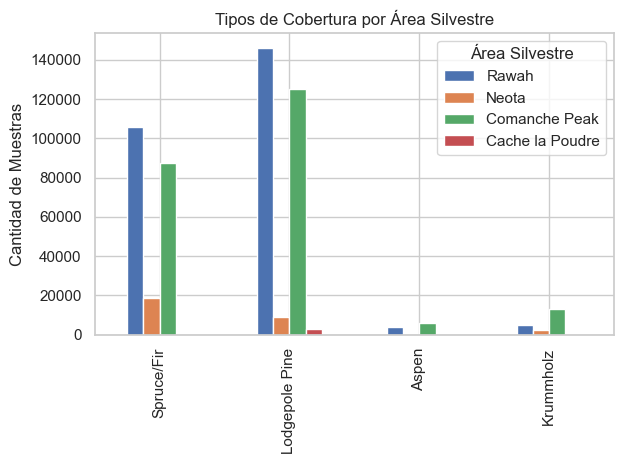

In [ ]:
# 10. Análisis de la relación entre áreas silvestres y tipos de cobertura
wilderness_cover = pd.DataFrame()
for i, area in enumerate(columnas_wilderness):
    temp_df = df[df[area] == 1]['Cover_Type'].value_counts().sort_index()
    wilderness_cover[f'Area {i+1}'] = temp_df

wilderness_cover.index = [etiquetas_clases[i] for i in wilderness_cover.index]
plt.figure(figsize=(14, 8))
wilderness_cover.plot(kind='bar', stacked=False)
plt.title('Tipos de Cobertura por Área Silvestre')
plt.ylabel('Cantidad de Muestras')
plt.legend(title='Área Silvestre', labels=['Rawah', 'Neota', 'Comanche Peak', 'Cache la Poudre'])
plt.tight_layout()
plt.show()

# 9. Análisis de los outliers


📊 Variable: Elevation
   Umbral inferior: 2119.41
   Umbral superior: 3799.32
   Outliers detectados: 5832


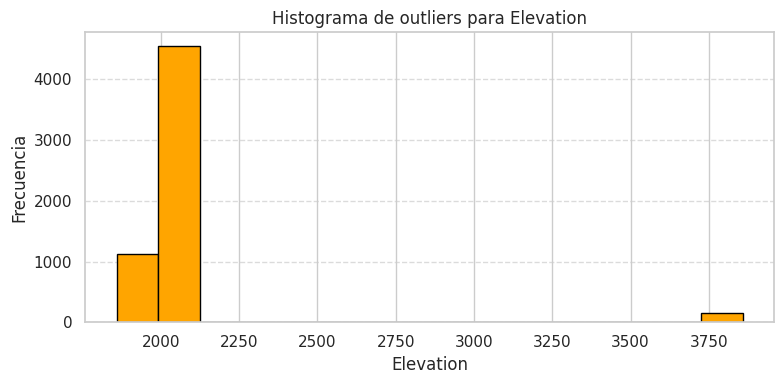


📊 Variable: Aspect
   Umbral inferior: -180.08
   Umbral superior: 491.40
   Outliers detectados: 0

📊 Variable: Slope
   Umbral inferior: -8.36
   Umbral superior: 36.57
   Outliers detectados: 4074


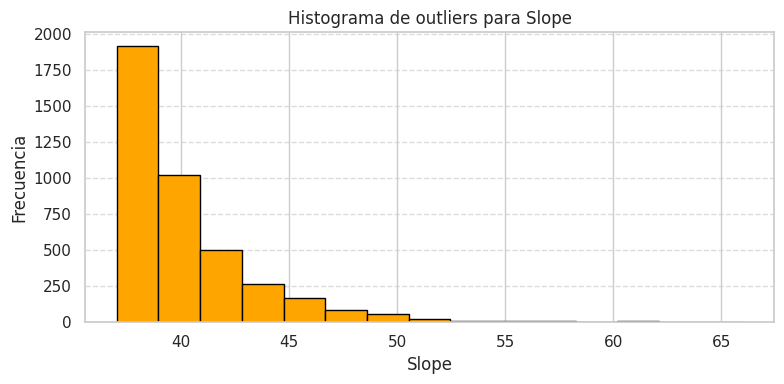


📊 Variable: Horizontal_Distance_To_Hydrology
   Umbral inferior: -368.22
   Umbral superior: 907.08
   Outliers detectados: 7073


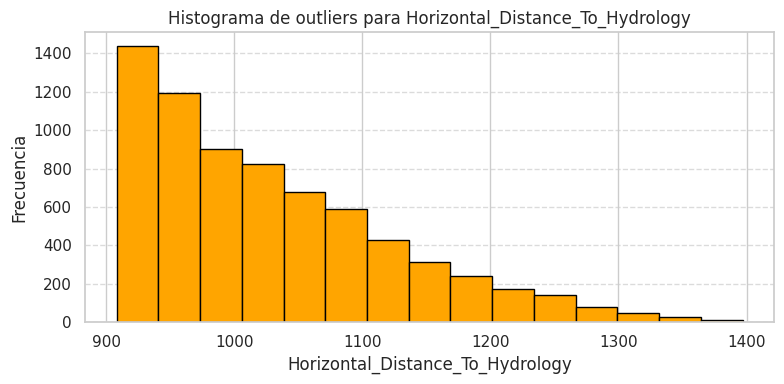


📊 Variable: Vertical_Distance_To_Hydrology
   Umbral inferior: -128.47
   Umbral superior: 221.30
   Outliers detectados: 10059


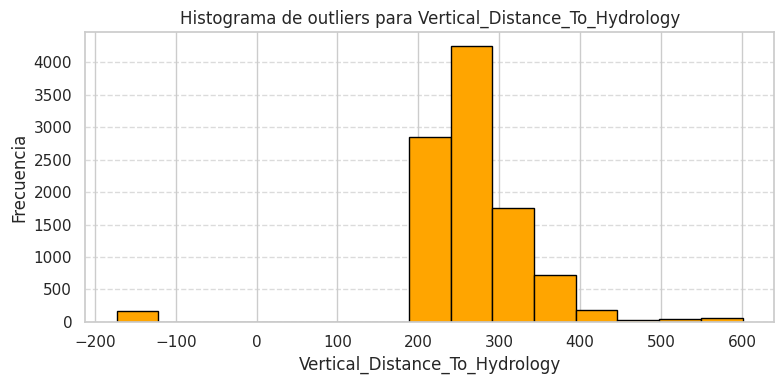


📊 Variable: Horizontal_Distance_To_Roadways
   Umbral inferior: -2327.61
   Umbral superior: 7027.91
   Outliers detectados: 33


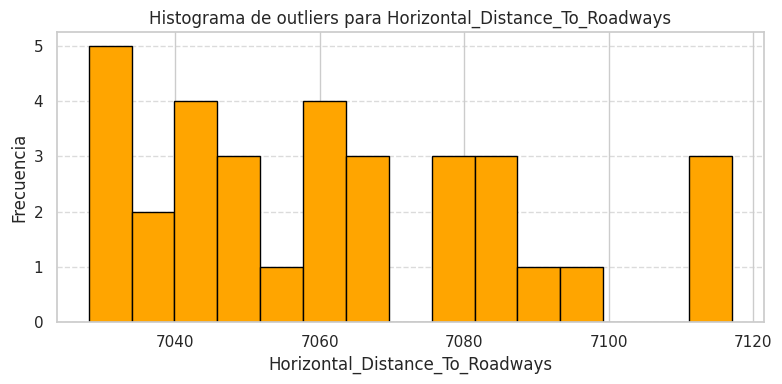


📊 Variable: Hillshade_9am
   Umbral inferior: 131.84
   Umbral superior: 292.46
   Outliers detectados: 7516


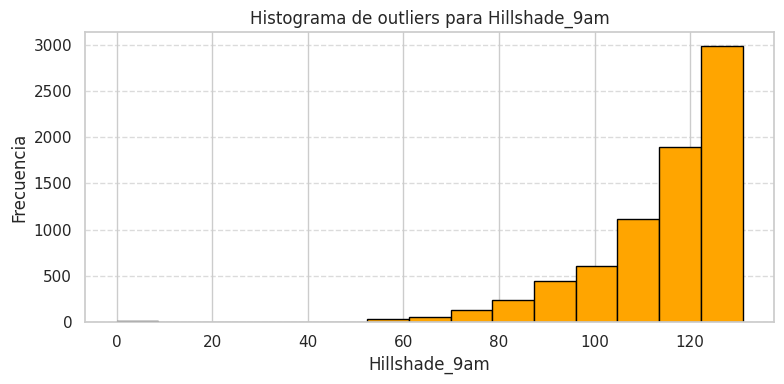


📊 Variable: Hillshade_Noon
   Umbral inferior: 164.01
   Umbral superior: 282.62
   Outliers detectados: 7082


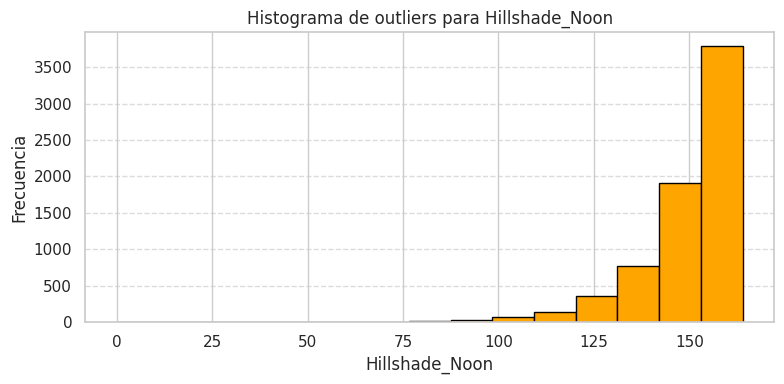


📊 Variable: Hillshade_3pm
   Umbral inferior: 27.70
   Umbral superior: 257.35
   Outliers detectados: 3042


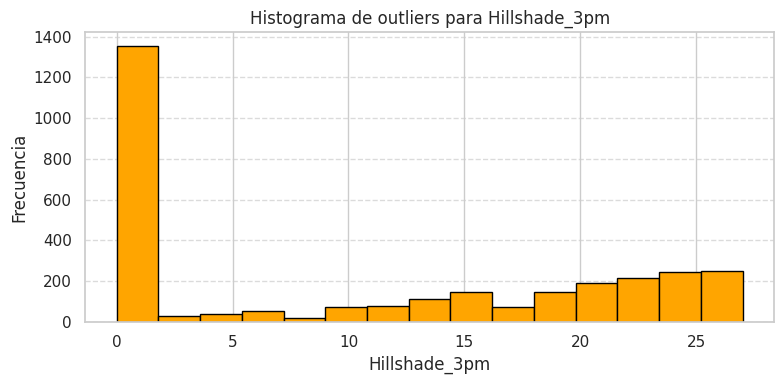


📊 Variable: Horizontal_Distance_To_Fire_Points
   Umbral inferior: -1992.29
   Umbral superior: 5952.87
   Outliers detectados: 10853


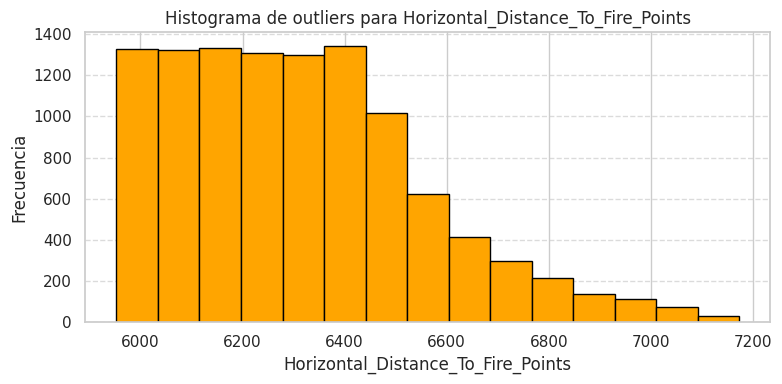


✅ Resumen de outliers identificados:
                             Variable Outliers
0                           Elevation     5832
1                               Slope     4074
2    Horizontal_Distance_To_Hydrology     7073
3      Vertical_Distance_To_Hydrology    10059
4     Horizontal_Distance_To_Roadways       33
5                       Hillshade_9am     7516
6                      Hillshade_Noon     7082
7                       Hillshade_3pm     3042
8  Horizontal_Distance_To_Fire_Points    10853


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Lista de columnas cuantitativas
columnas_cuantitativas = [
    'Elevation', 'Aspect', 'Slope',
    'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways', 'Hillshade_9am',
    'Hillshade_Noon', 'Hillshade_3pm',
    'Horizontal_Distance_To_Fire_Points'
]

# Crear un DataFrame vacío para registrar los outliers
outliers = pd.DataFrame(columns=['Variable', 'Outliers'])

# Iterar sobre las variables numéricas
for column in columnas_cuantitativas:
    # Calcular los Z-scores
    z_scores = np.abs(stats.zscore(df[column], nan_policy='omit'))

    # Identificar índices de outliers (Z > 3)
    outlier_indices = np.where(z_scores > 3)[0]

    # Calcular media y desviación estándar
    mu = np.mean(df[column])
    sigma = np.std(df[column])

    # Calcular los límites superior e inferior
    upper_bound = mu + 3 * sigma
    lower_bound = mu - 3 * sigma

    print(f"\n📊 Variable: {column}")
    print(f"   Umbral inferior: {lower_bound:.2f}")
    print(f"   Umbral superior: {upper_bound:.2f}")
    print(f"   Outliers detectados: {len(outlier_indices)}")

    # Si hay outliers, registrarlos y graficar
    if len(outlier_indices) > 0:
        outliers = pd.concat([
            outliers,
            pd.DataFrame([{'Variable': column, 'Outliers': len(outlier_indices)}])
        ], ignore_index=True)

        # Graficar histograma de los outliers
        plt.figure(figsize=(8, 4))
        plt.hist(df[column].iloc[outlier_indices], bins=15, color='orange', edgecolor='black')
        plt.title(f'Histograma de outliers para {column}')
        plt.xlabel(column)
        plt.ylabel('Frecuencia')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

# Mostrar resumen final
print("\n✅ Resumen de outliers identificados:")
print(outliers)




Variable: Elevation
Q1 (25 percentil): 2809.00
Q3 (75 percentil): 3163.00
Rango IQR: 354.00
Umbral inferior: 2278.00
Umbral superior: 3694.00


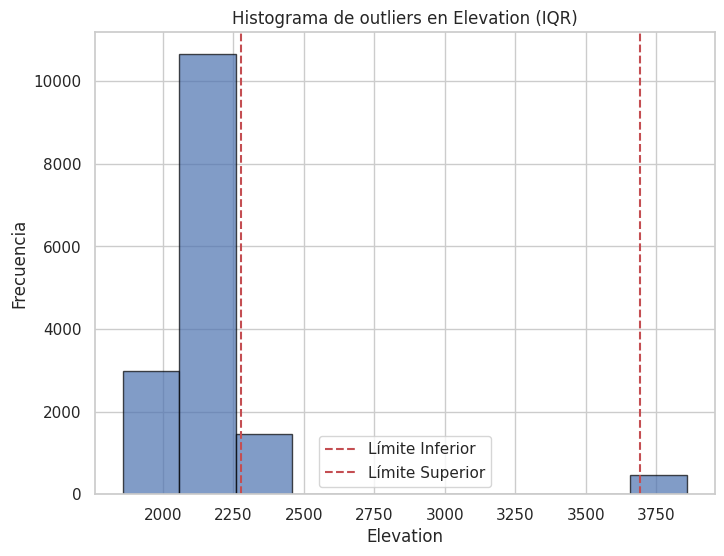


Variable: Slope
Q1 (25 percentil): 9.00
Q3 (75 percentil): 18.00
Rango IQR: 9.00
Umbral inferior: -4.50
Umbral superior: 31.50


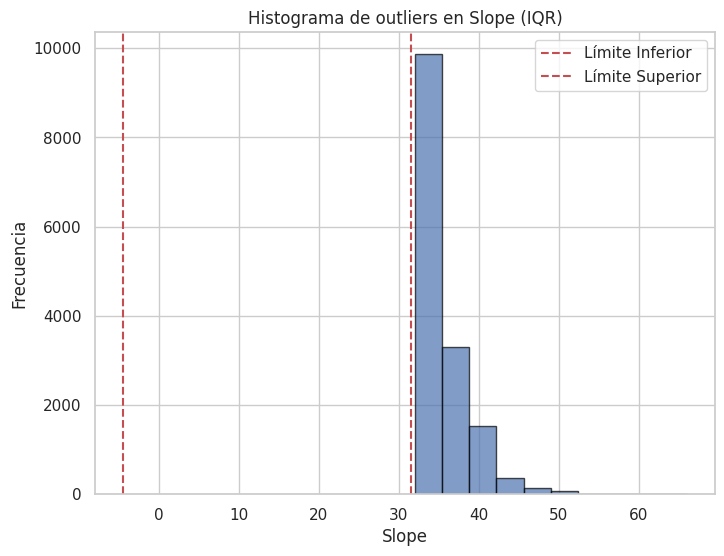


Variable: Horizontal_Distance_To_Hydrology
Q1 (25 percentil): 108.00
Q3 (75 percentil): 384.00
Rango IQR: 276.00
Umbral inferior: -306.00
Umbral superior: 798.00


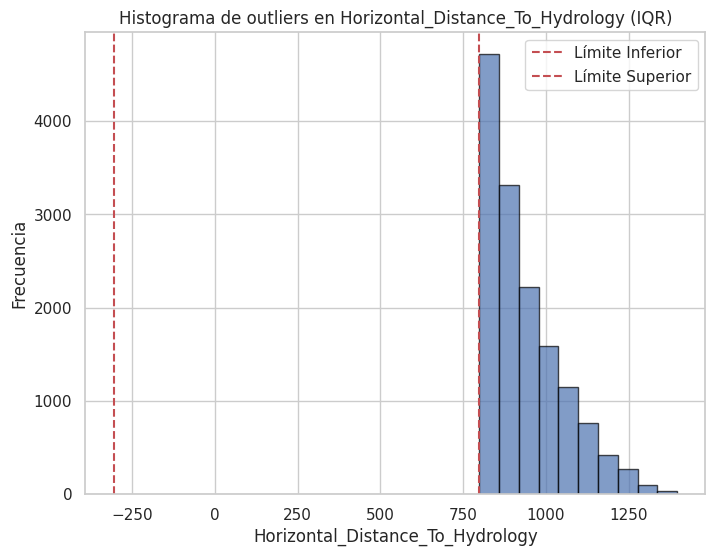


Variable: Vertical_Distance_To_Hydrology
Q1 (25 percentil): 7.00
Q3 (75 percentil): 69.00
Rango IQR: 62.00
Umbral inferior: -86.00
Umbral superior: 162.00


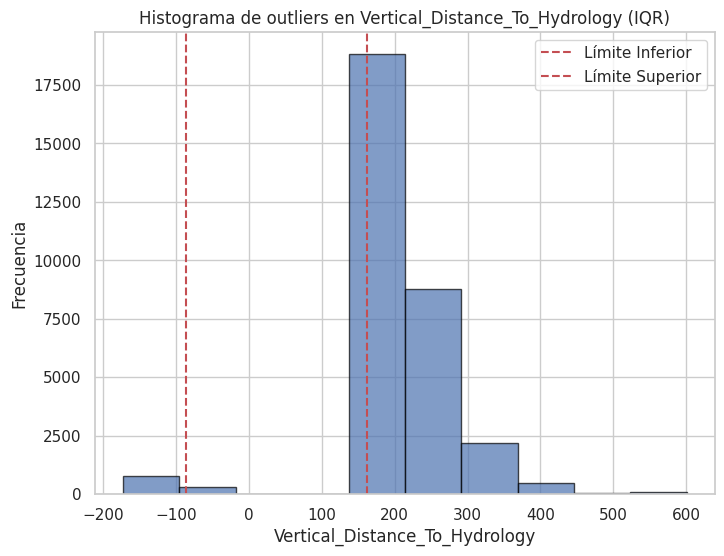


Variable: Horizontal_Distance_To_Roadways
Q1 (25 percentil): 1106.00
Q3 (75 percentil): 3328.00
Rango IQR: 2222.00
Umbral inferior: -2227.00
Umbral superior: 6661.00


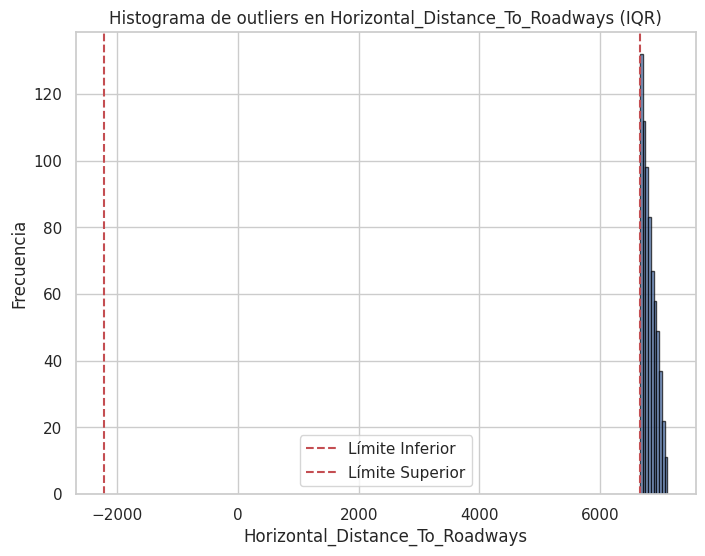


Variable: Hillshade_9am
Q1 (25 percentil): 198.00
Q3 (75 percentil): 231.00
Rango IQR: 33.00
Umbral inferior: 148.50
Umbral superior: 280.50


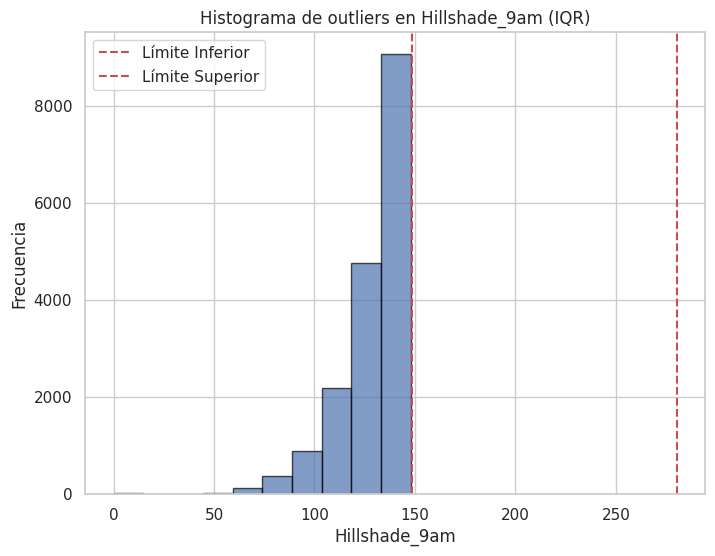


Variable: Hillshade_Noon
Q1 (25 percentil): 213.00
Q3 (75 percentil): 237.00
Rango IQR: 24.00
Umbral inferior: 177.00
Umbral superior: 273.00


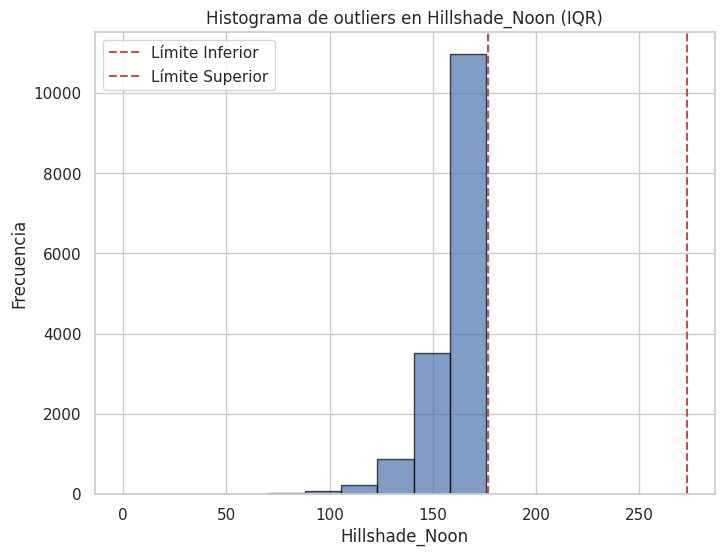


Variable: Hillshade_3pm
Q1 (25 percentil): 119.00
Q3 (75 percentil): 168.00
Rango IQR: 49.00
Umbral inferior: 45.50
Umbral superior: 241.50


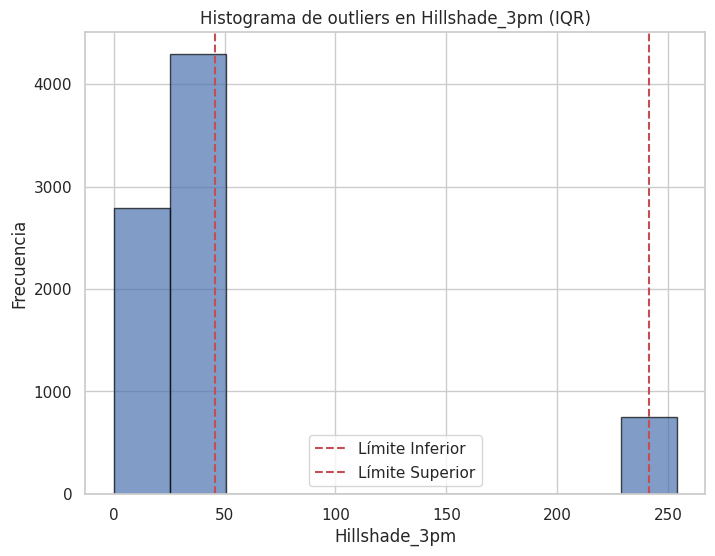


Variable: Horizontal_Distance_To_Fire_Points
Q1 (25 percentil): 1024.00
Q3 (75 percentil): 2550.00
Rango IQR: 1526.00
Umbral inferior: -1265.00
Umbral superior: 4839.00


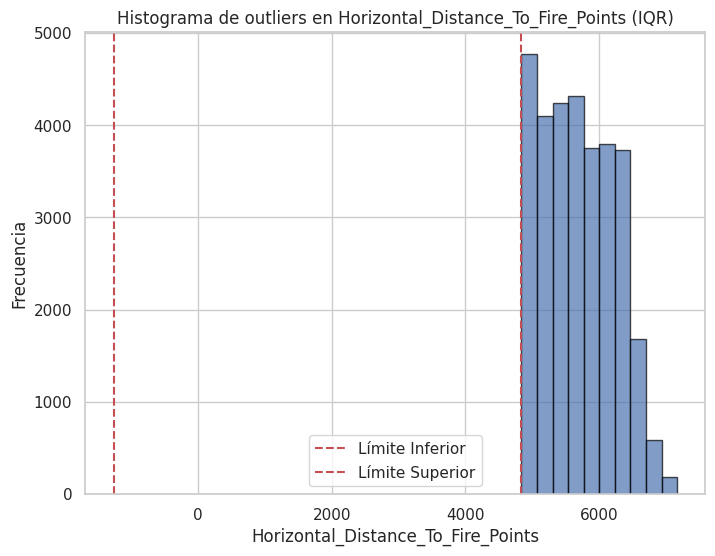


Outliers identificados mediante IQR:
                             Variable Outliers
0                           Elevation    15569
1                               Slope    15316
2    Horizontal_Distance_To_Hydrology    14557
3      Vertical_Distance_To_Hydrology    31463
4     Horizontal_Distance_To_Roadways      669
5                       Hillshade_9am    17433
6                      Hillshade_Noon    15672
7                       Hillshade_3pm     7832
8  Horizontal_Distance_To_Fire_Points    31157


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# DataFrame para registrar los outliers
outliers = pd.DataFrame(columns=['Variable', 'Outliers'])

# Iterar sobre las variables numéricas
for column in columnas_cuantitativas:
    df_col_dropna = df[column].dropna()

    Q1 = df_col_dropna.quantile(0.25)
    Q3 = df_col_dropna.quantile(0.75)
    IQR = Q3 - Q1

    # Límites inferior y superior para detectar outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filtrar los valores que están fuera de los límites
    outliers_values = df_col_dropna[(df_col_dropna < lower_bound) | (df_col_dropna > upper_bound)]

    if len(outliers_values) > 0:
        # Agregar fila al DataFrame de outliers
        new_row = pd.DataFrame([{'Variable': column, 'Outliers': len(outliers_values)}])
        outliers = pd.concat([outliers, new_row], ignore_index=True)

        print(f"\nVariable: {column}")
        print(f"Q1 (25 percentil): {Q1:.2f}")
        print(f"Q3 (75 percentil): {Q3:.2f}")
        print(f"Rango IQR: {IQR:.2f}")
        print(f"Umbral inferior: {lower_bound:.2f}")
        print(f"Umbral superior: {upper_bound:.2f}")

        # Histograma de outliers
        plt.figure(figsize=(8, 6))
        plt.hist(outliers_values, bins=10, edgecolor='black', alpha=0.7)
        plt.axvline(lower_bound, color='r', linestyle='--', label='Límite Inferior')
        plt.axvline(upper_bound, color='r', linestyle='--', label='Límite Superior')
        plt.title(f"Histograma de outliers en {column} (IQR)")
        plt.xlabel(column)
        plt.ylabel('Frecuencia')
        plt.legend()
        plt.show()

# Mostrar resumen final
print("\nOutliers identificados mediante IQR:")
print(outliers)


| Variable                               | Outliers (IQR) | Outliers (Z-score) |
| -------------------------------------- | -------------- | ------------------ |
| Elevation                              | 15,569         | 5,832              |
| Slope                                  | 15,316         | 4,074              |
| Horizontal\_Distance\_To\_Hydrology    | 14,557         | 7,073              |
| Vertical\_Distance\_To\_Hydrology      | 31,463         | 10,059             |
| Horizontal\_Distance\_To\_Roadways     | 669            | 33                 |
| Hillshade\_9am                         | 17,433         | 7,516              |
| Hillshade\_Noon                        | 15,672         | 7,082              |
| Hillshade\_3pm                         | 7,832          | 3,042              |
| Horizontal\_Distance\_To\_Fire\_Points | 31,157         | 10,853             |

Debido a que no se considera que haya un gran número de outliers respecto a las filas totales, que estos mismos outliers se consideran como medidas o valores legítimos y con sentido y finalmente que es probable que se utilice un modelo random forrest en la fase de predicción (que no es demasiado sensible a valores atípicos), se ha optado por no quitarlos y dejar que permanezcan.